# Olist BI: análise exploratória de vendas

Notebook de apoio ao projeto de Business Intelligence sobre a base Olist Brazilian E Commerce. Aqui a conexão é feita direto no banco SQLite gerado pelo ETL e cada pergunta de negócio é respondida com SQL e visualizada com pandas e matplotlib.

Antes de rodar este notebook, execute `python/01_etl_build_model.py` para gerar `data/olist.db`.

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DB = Path("..") / "data" / "olist.db"
con = sqlite3.connect(DB)

def q(sql):
    return pd.read_sql_query(sql, con)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Conectado ao banco:", DB.resolve())

Conectado ao banco: /home/claude/olist_bi/data/olist.db


## 1. Conhecendo o modelo

O ETL entregou um esquema estrela: uma fato no grão de item de pedido e cinco dimensões.

In [2]:
tabelas = q("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
for t in tabelas['name']:
    n = q(f"SELECT COUNT(*) c FROM {t}")['c'][0]
    print(f"{t:20s} {n:>7} linhas")

dim_customer           99441 linhas
dim_date                 634 linhas
dim_order              99441 linhas
dim_product            32951 linhas
dim_seller              3095 linhas
fact_order_items      112650 linhas


## 2. KPIs principais

Sempre filtrando por pedidos entregues, para não inflar a receita com pedidos cancelados.

In [3]:
q('''
SELECT COUNT(DISTINCT f.order_id) AS pedidos,
       ROUND(SUM(f.total_item_value),2) AS receita_total,
       ROUND(SUM(f.total_item_value)/COUNT(DISTINCT f.order_id),2) AS ticket_medio
FROM fact_order_items f
JOIN dim_order o ON o.order_id = f.order_id
WHERE o.order_status = 'delivered'
''')

,pedidos,receita_total,ticket_medio
0,96478,15419773.75,159.83


## 3. Evolução do faturamento

Uso de função de janela LAG para calcular o crescimento mês a mês direto no SQL.

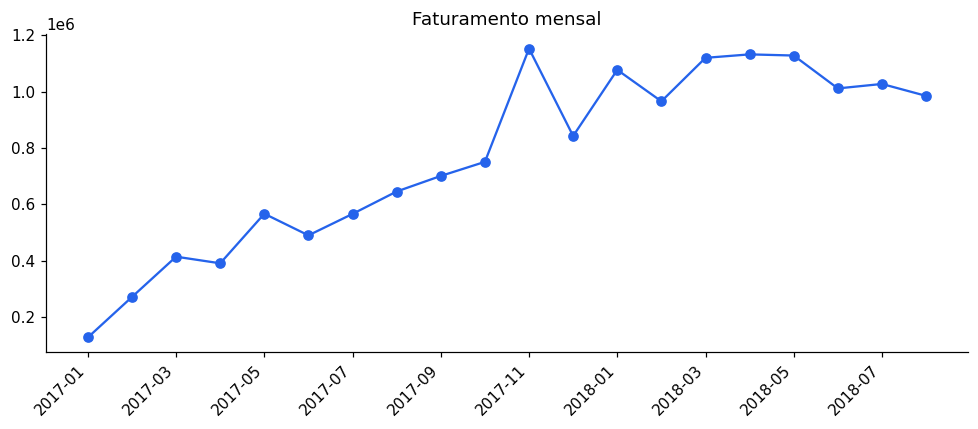

,year_month,receita,crescimento_pct
15,2018-04,1132878.93,1.1
16,2018-05,1128774.52,-0.4
17,2018-06,1011978.29,-10.3
18,2018-07,1027807.28,1.6
19,2018-08,985491.64,-4.1


In [4]:
mensal = q('''
WITH r AS (
  SELECT d.year_month, SUM(f.total_item_value) AS receita
  FROM fact_order_items f
  JOIN dim_order o ON o.order_id=f.order_id
  JOIN dim_date d ON d.date_key=f.date_key
  WHERE o.order_status='delivered' AND d.year_month BETWEEN '2017-01' AND '2018-08'
  GROUP BY d.year_month)
SELECT year_month, receita,
       ROUND(100.0*(receita-LAG(receita) OVER (ORDER BY year_month))
             /LAG(receita) OVER (ORDER BY year_month),1) AS crescimento_pct
FROM r ORDER BY year_month
''')
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(mensal['year_month'], mensal['receita'], marker='o', color='#2563eb')
ax.set_title('Faturamento mensal'); ax.set_xticks(mensal['year_month'][::2])
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
mensal.tail()

## 4. O insight central: atraso derruba a nota

Agrupando os pedidos por faixa de pontualidade, fica claro que a satisfação despenca quando há atraso. Logística é o principal motor da nota.

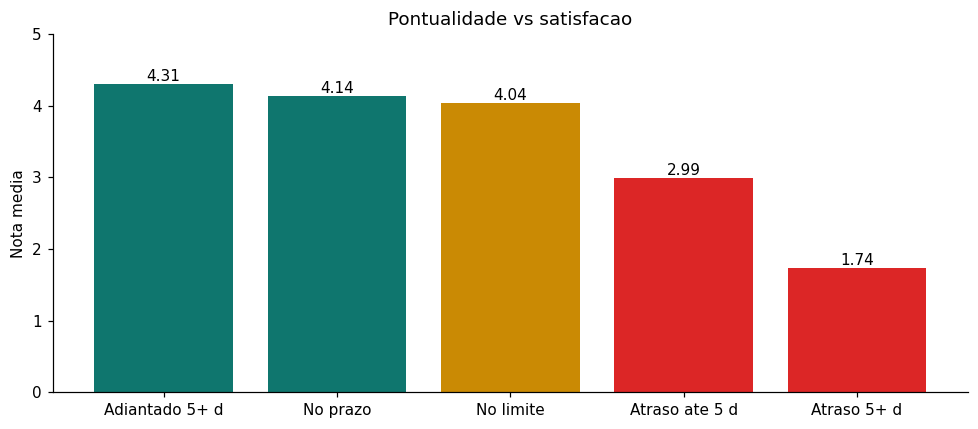

,faixa,pedidos,nota_media
0,Adiantado 5+ d,81555,4.31
1,No prazo,6608,4.14
2,No limite,1280,4.04
3,Atraso ate 5 d,2722,2.99
4,Atraso 5+ d,3659,1.74


In [5]:
faixa = q('''
SELECT CASE
         WHEN delay_days <= -5 THEN 'Adiantado 5+ d'
         WHEN delay_days < 0 THEN 'No prazo'
         WHEN delay_days = 0 THEN 'No limite'
         WHEN delay_days <= 5 THEN 'Atraso ate 5 d'
         ELSE 'Atraso 5+ d' END AS faixa,
       COUNT(*) AS pedidos, ROUND(AVG(review_score),2) AS nota_media
FROM dim_order
WHERE order_status='delivered' AND delay_days IS NOT NULL AND review_score IS NOT NULL
GROUP BY faixa
''')
ordem = ['Adiantado 5+ d','No prazo','No limite','Atraso ate 5 d','Atraso 5+ d']
faixa = faixa.set_index('faixa').loc[ordem].reset_index()
cores = ['#0f766e','#0f766e','#ca8a04','#dc2626','#dc2626']
fig, ax = plt.subplots(figsize=(9,4))
b = ax.bar(faixa['faixa'], faixa['nota_media'], color=cores)
ax.bar_label(b, fmt='%.2f'); ax.set_ylim(0,5); ax.set_ylabel('Nota media')
ax.set_title('Pontualidade vs satisfacao'); plt.tight_layout(); plt.show()
faixa

## 5. Segmentação RFM

Recência, frequência e valor por cliente real, com NTILE criando quartis e um CASE traduzindo em segmentos de negócio.

In [6]:
q('''
WITH base AS (
  SELECT c.customer_unique_id, MAX(o.purchase_date) ultima,
         COUNT(DISTINCT f.order_id) freq, SUM(f.total_item_value) valor
  FROM fact_order_items f
  JOIN dim_order o ON o.order_id=f.order_id
  JOIN dim_customer c ON c.customer_id=f.customer_id
  WHERE o.order_status='delivered'
  GROUP BY c.customer_unique_id),
s AS (
  SELECT NTILE(4) OVER (ORDER BY ultima DESC) r,
         NTILE(4) OVER (ORDER BY valor ASC) m, valor FROM base)
SELECT CASE WHEN r>=3 AND m>=3 THEN 'Alto valor'
            WHEN r>=3 AND m<3 THEN 'Recente em desenvolvimento'
            WHEN r<3 AND m>=3 THEN 'Em risco de churn'
            ELSE 'Baixo engajamento' END segmento,
       COUNT(*) clientes, ROUND(AVG(valor),2) valor_medio
FROM s GROUP BY segmento ORDER BY valor_medio DESC
''')

,segmento,clientes,valor_medio
0,Alto valor,22832,267.65
1,Em risco de churn,23846,265.95
2,Recente em desenvolvimento,23846,63.95
3,Baixo engajamento,22834,63.15


## Conclusão

Três frentes saltam dos dados: receita concentrada em poucas categorias, retenção baixíssima (espaço claro para CRM) e a entrega no prazo como variável que mais move a satisfação. Esses achados viram o roteiro do dashboard descrito em `dashboard/README.md`.

In [7]:
con.close()